Лабораторная работа №5.1
Сайт: https://primpress.ru/

Была создана база данных SQLite под названием primpress.db

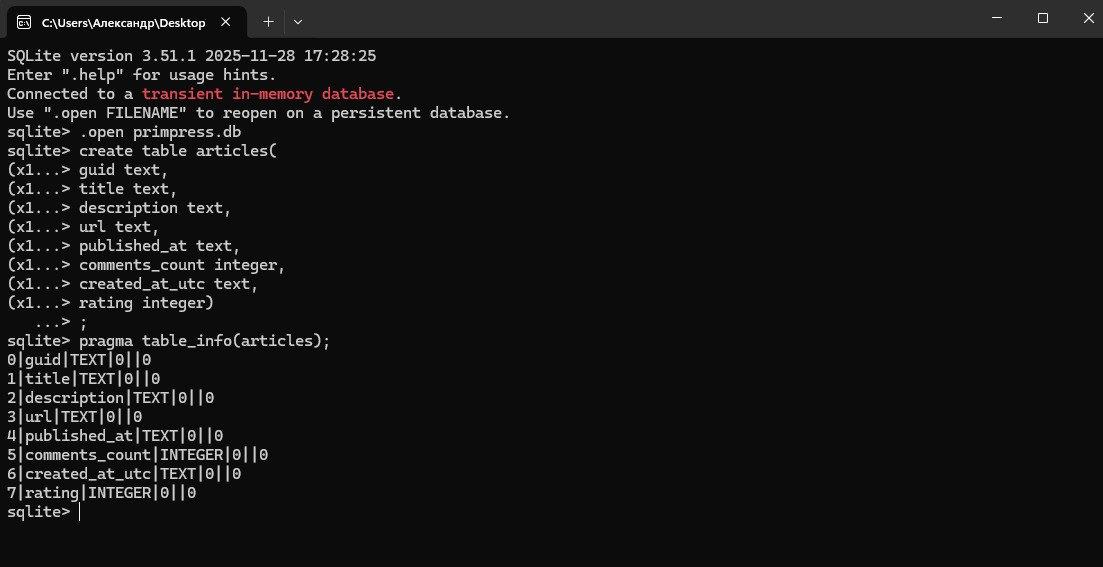

Для сбора статей с сайта в базу данных был написан код на языке программировани Python с использованием библиотек requests, bs4 и других

In [ ]:
import requests
from bs4 import BeautifulSoup
import uuid
import datetime
import sqlite3
import time
import random

start_time = time.time()

connection = sqlite3.connect(r"C:\Users\Александр\Desktop\primpress.db")

cursor = connection.cursor()

Создаётся подключение к базе данных и создаётся объект cursor, который c помощью которого осуществляется взаимодействие с базой данных

In [ ]:
RU_MONTHS = {
    'января': 1, 'февраля': 2, 'марта': 3, 'апреля': 4,
    'мая': 5, 'июня': 6, 'июля': 7, 'августа': 8,
    'сентября': 9, 'октября': 10, 'ноября': 11, 'декабря': 12
}

def ru_to_iso(dt_str: str) -> str:
    s = dt_str.strip()

    date_part, time_part = [p.strip() for p in s.split(',', 1)]

    day_str, month_str, year_str = date_part.split()
    day = int(day_str)
    month = RU_MONTHS[month_str.lower()]
    year = int(year_str)

    hour, minute = [int(x) for x in time_part.split(':', 1)]
    dt = datetime.datetime(year, month, day, hour, minute, 0)
    return dt.strftime('%Y-%m-%d %H:%M:%S')

Функция ru_to_iso конвертирует дату с сайта к виду utc

In [ ]:
def articles(url):
    try:
        resp = requests.get(url)
    except requests.exceptions.ConnectionError:
        return 'Соединение не возможно', []

    html = resp.text

    soup = BeautifulSoup(html, 'html.parser')

    guid = str(uuid.uuid4())

    title = soup.title.string.strip()

    description = ''
    for t in soup.findAll('p'):
        description = description + '\n\n' + t.get_text()

    try:
        published_at = ru_to_iso(soup.find('span', {'title' : 'Дата публикации'}).get_text().strip())
    except ValueError:
        published_at = None

    comments_count = None

    created_at_utc = str(datetime.datetime.now())[:19]

    rating = None

    cursor.execute('INSERT INTO articles (guid, title, description, url, published_at, comments_count, created_at_utc, rating) VALUES (?, ?, ?, ?, ?, ?, ?, ?)',
        (guid, title, description, url, published_at, comments_count, created_at_utc, rating))

    return title

Функция articles принимает на вход url статьи, получает со страницы html код и вычленяет из него необходимые элементы, а также создает другие необходимые объекты. Когда все данные получены функция записывает их в базу данных, а после возвращает название статьи.

In [ ]:
i = 1
n = 1
while i < 220:
    resp = requests.get(f'https://primpress.ru/news?page={i}')

    html = resp.text

    soup = BeautifulSoup(html, 'html.parser')

    ref = soup.findAll('a')
    for x in ref:
        if x['href'][:28] == 'https://primpress.ru/article':
            print(f'{n}.', articles(x['href']))
            n += 1

    i += 1

На сайте можно найти раздел с лентой новостей, который показывает первую страницу с последними новостями

Изменяя в url номер страницы мы перейдём на другую страницу. Таким образом переходя поочередно по страницам мы будем получать новые новости. Найдя все ссылки со страницы переберём их все поочередно и оставим только те, которые соответсвуют шаблону https://primpress.ru/article и от них мы будем вызывать функцию. В консоль выведем номер записанной статьи и её название.

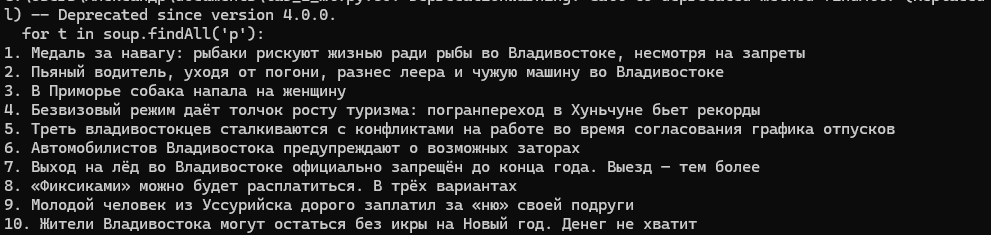

In [ ]:
connection.commit()

connection.close()

end_time = time.time()

print()
print(f'Время: {(end_time - start_time)//3600:.0f}:{((end_time - start_time)%3600)//60:.0f}')

Сохраним изменения в базе данных, закроем соединение и выведем время, которое заняла работа кода